# Daily air pollutant summaries from regulatory monitors

EPA's Air Quality System (AQS) is the archive of regulatory air monitoring:
state, local, and tribal agencies submit, validate, and certify it. The
`dailyData` service returns one JSON document per request, with a row per
monitor, local day, and pollutant standard: the day's mean and maximum, the
hour of the maximum, the AQI where the standard defines one, and how
complete the day was.

This walkthrough pulls every daily PM2.5 summary for 2023 from one monitoring
site, Queens College in New York City, where Canadian wildfire smoke arrived
in June. It needs `usdata[pandas]`, matplotlib, and an AQS key; the one
request takes one to two minutes.

AQS requires a registered email and key in every request. Set
`USDATA_AQS_EMAIL` and `USDATA_AQS_KEY` in the environment first; the
[AQS guide](https://docs.usdata.dev/providers/epa-aqs-daily/) says how to get
them. No key reaches the manifest, the lockfile, the cached file, or any
output below.

In [1]:
from datetime import UTC, datetime
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

import usdata
from usdata import cite_lockfile, pull, verify

# One figure style for every usdata notebook, so previews look alike.
plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 10,
    }
)
manifest = Path("dataset.yaml")
print("Executed (UTC):", datetime.now(UTC).isoformat(timespec="seconds"))
print(f"usdata {usdata.__version__}; pandas {pd.__version__}")

Executed (UTC): 2026-09-24T05:55:41+00:00
usdata 0.26.0; pandas 3.0.6


## Select

The manifest names one parameter code, one site, and a window. `88101` is
PM2.5 measured at local conditions; `36-081-0124` is state 36 (New York),
county 081 (Queens), site 0124 (Queens College). The service refuses a
request that spans two calendar years, so usdata makes one request, and
writes one file, per year the window touches: here, one.

In [2]:
print(manifest.read_text())

name: queens-college-pm25-2023
sources:
  - name: pm25
    dataset: epa:aqs-daily
    start: 2023-01-01
    end: 2023-12-31
    params:
      parameters: 88101
      sites: 36-081-0124



## What arrives

One JSON file. It is not the bytes as sent: AQS echoes the whole request,
key included, in its header, and its row order and `request_time` change
between identical requests. usdata writes a canonical form instead, the
header without `url` and `request_time`, rows in a fixed order, keys sorted,
and records that step in the provenance, so a checksum can pin it.

In [3]:
result = pull(manifest)
(item,) = result.fetched
print("File:", item.path.name)
print("Bytes:", item.provenance.size)
print("Retrieved (UTC):", item.provenance.retrieved_at.isoformat(timespec="seconds"))
print("Checksum:", item.provenance.checksum)
print("Transformations:", item.provenance.transformations)
print("Credentials used:", item.provenance.credentials)

File: aqs-daily_site-36-081-0124_88101_20230101_20231231.json
Bytes: 5529304
Retrieved (UTC): 2026-09-24T05:55:56+00:00
Checksum: sha256:4a26cfcb1a5596f8670413455fc31ff03337b128775741f864875cede0fe0c08
Transformations: ['aqs canonical json: Header url and request_time removed; Data sorted by site, parameter, poc, local date, duration, standard, method, and event type']
Credentials used: ['USDATA_AQS_EMAIL', 'USDATA_AQS_KEY']


## Open

The reader returns one row per element of the service's `Data` list, with the
columns as AQS names them. `date_local` is a day in the monitor's local
standard time, parsed as a naive date. Several rows describe one monitor on
one day: once per pollutant standard the day is compared with, once more for
the hourly series, and again when an agency flagged an exceptional event.

In [4]:
pm25 = item.open()
print(f"{len(pm25)} rows, {pm25.date_local.min():%Y-%m-%d} to {pm25.date_local.max():%Y-%m-%d}")
pm25.groupby(["pollutant_standard", "sample_duration", "event_type"], dropna=False).size().rename(
    "rows"
).to_frame()

6161 rows, 2023-01-01 to 2023-12-31


rows
pollutant_standard sample_duration event_type                     
PM25 24-hour 1997  24 HOUR         No Events                   119
                   24-HR BLK AVG   Events Included             194
                                   No Events                   363
PM25 24-hour 2006  24 HOUR         No Events                   119
                   24-HR BLK AVG   Events Included             194
                                   No Events                   363
PM25 24-hour 2012  24 HOUR         No Events                   119
                   24-HR BLK AVG   Events Included             194
                                   No Events                   363
PM25 24-hour 2024  24 HOUR         No Events                   119
                   24-HR BLK AVG   Events Included             194
                                   No Events                   363
PM25 Annual 1997   24 HOUR         No Events                   119
                   24-HR BLK AVG   Events Included             194
                                   No Events                   363
PM25 Annual 2006   24 HOUR         No Events                   119
                   24-HR BLK AVG   Events Included             194
                                   No Events                   363
PM25 Annual 2012   24 HOUR         No Events                   119
                   24-HR BLK AVG   Events Included             194
                                   No Events                   363
PM25 Annual 2024   24 HOUR         No Events                   119
                   24-HR BLK AVG   Events Included             194
                                   No Events                   363
NaN                1 HOUR          Concurred Events Excluded   194
                                   Events Included             194
                                   No Events                   365

To count days, keep one row per monitor and day: the current daily standard,
`PM25 24-hour 2024`, and the rows that describe what was measured
(`No Events` and `Events Included`), not the ones with flagged days removed.

In [5]:
daily = pm25[
    (pm25.pollutant_standard == "PM25 24-hour 2024")
    & ~pm25.event_type.isin(["Events Excluded", "Concurred Events Excluded"])
]
assert not daily.duplicated(["poc", "date_local"]).any()
print(f"{len(daily)} monitor-days from {daily.poc.nunique()} instruments (POC)")
daily[["date_local", "poc", "sample_duration", "arithmetic_mean", "aqi", "event_type"]].head()

676 monitor-days from 3 instruments (POC)


,date_local,poc,sample_duration,arithmetic_mean,aqi,event_type
3,2023-01-03,1,24 HOUR,16.9,66.0,No Events
11,2023-01-06,1,24 HOUR,5.0,28.0,No Events
19,2023-01-09,1,24 HOUR,8.3,46.0,No Events
27,2023-01-12,1,24 HOUR,5.9,33.0,No Events
35,2023-01-15,1,24 HOUR,3.0,17.0,No Events


## A first look

A year of daily means from each instrument at the site, against the 35 µg/m³
daily standard.

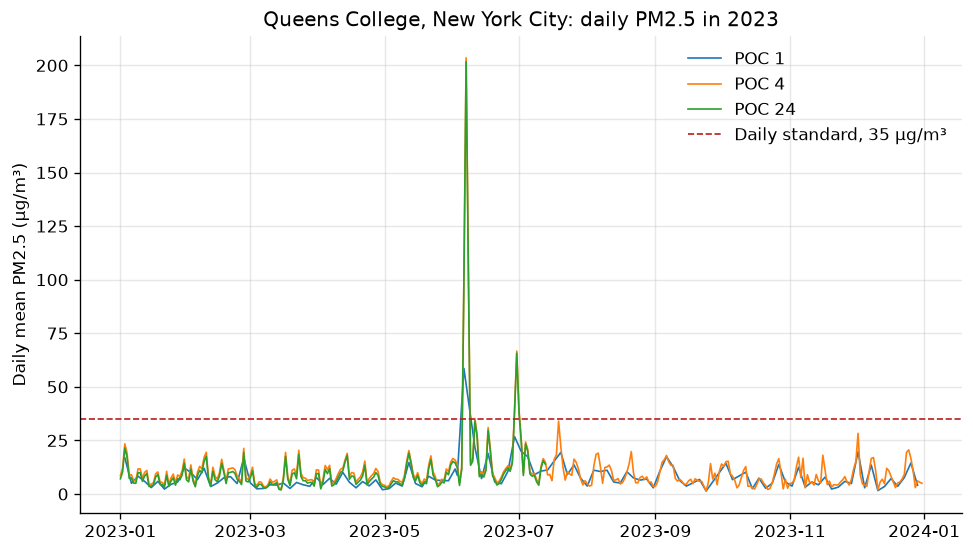

In [6]:
fig, ax = plt.subplots(layout="constrained")
for poc, series in daily.sort_values("date_local").groupby("poc"):
    ax.plot(series.date_local, series.arithmetic_mean, linewidth=1, label=f"POC {poc}")
ax.axhline(35, color="#b91c1c", linewidth=1, linestyle="--", label="Daily standard, 35 µg/m³")
ax.set_ylabel("Daily mean PM2.5 (µg/m³)")
ax.set_title("Queens College, New York City: daily PM2.5 in 2023")
ax.legend(frameon=False)
plt.show()

In [7]:
peak = daily.loc[daily.arithmetic_mean.idxmax()]
over = daily[daily.arithmetic_mean > 35]
print(f"Highest daily mean: {peak.arithmetic_mean:.1f} µg/m³ on {peak.date_local:%d %B}")
print(f"Its AQI: {peak.aqi:.0f}")
print(f"Days above 35 µg/m³ at any instrument: {over.date_local.dt.date.nunique()}")
print("Those days:", ", ".join(f"{day:%d %b}" for day in sorted(set(over.date_local))))

Highest daily mean: 203.5 µg/m³ on 07 June
Its AQI: 278
Days above 35 µg/m³ at any instrument: 7
Those days: 06 Jun, 07 Jun, 08 Jun, 11 Jun, 29 Jun, 30 Jun, 01 Jul


The year sits well under the standard apart from two episodes, 6 to 11 June
and 29 June to 1 July, when smoke from Canadian wildfires reached the city.
The
[wildfire-smoke study](https://usdata.dev/studies/wildfire-smoke/) follows
those days across every monitor in the city.

## Pin and cite

`verify` checks the cached file against the lockfile's checksum without a
key. Agencies revise AQS data, and each row carries `date_of_last_change`,
so a later pull can report drift; `pull --update` accepts a revision
deliberately.

In [8]:
assert verify(manifest) == []
print("Latest revision in the file:", f"{pm25.date_of_last_change.max():%Y-%m-%d}")
for citation in cite_lockfile(manifest):
    print(citation.as_text())

Latest revision in the file: 2024-06-17
epa:aqs-daily
  U.S. Environmental Protection Agency, Air Quality System (AQS) daily summary data, AQS Data API, accessed via usdata
  homepage: https://aqs.epa.gov/aqsweb/documents/data_api.html#daily
  license: US Government Work (public domain)
  terms: https://aqs.epa.gov/aqsweb/documents/data_api.html#terms
  retrieved: 2026-09-24; 1 checksummed asset (5,529,304 bytes) pinned by usdata 0.26.0
  sources: pm25


## What was awkward

- One monitor-day is up to nine rows: eight PM2.5 standards plus the hourly
  series. Counting rows above 35 µg/m³ counts most days several times;
  filtering to one standard is the fix, and nothing in the file says to.
- Exceptional events are not flagged by day. A monitor with any flagged event
  gets an `Events Included` copy of its rows, so filtering on the event type
  decides whether smoke days are in or out of the count.
- A mistyped parameter code returns the same "No data matched your
  selection" as a real code with no monitors, and arrives as a file with no
  rows.
- It is slow: a site-year is one request that takes a minute or two, and EPA
  asks for pauses between requests, which the adapter enforces.